# StormScope Nowcasting Over Wyoming




This notebook runs the **StormScope** nowcasting system from [Earth2Studio](https://github.com/NVIDIA/earth2studio) and focuses the analysis on **Wyoming** : a region squarely inside the famous "Hail Alley" corridor along the Colorado–Wyoming Front Range, where high-based High Plains convection, terrain-driven initiation, and fast storm motion make short-fuse nowcasting genuinely hard (and genuinely useful).

## What is StormScope? 
StormScope is NVIDIA’s observation-driven AI nowcasting model family for predicting the evolution of storms, clouds, precipitation, and related mesoscale features over roughly the next 0–6 hours. Instead of forecasting the full atmospheric state like FourCastNet, Atlas, or a traditional NWP model, it forecasts what the observing systems themselves will see; primarily satellite imagery and radar.

StormScope is an observation-to-observation generative AI nowcasting model that uses recent satellite, radar, and lightning observations to predict the evolution of storm-scale weather over the next several hours.


Two coupled prognostic models are used here:

| Model | State it forecasts | Conditioning | Grid |
|---|---|---|---|
| `StormScopeGOES` | 8 GOES ABI channels (`abi01c, abi02c, abi03c, abi07c, abi08c, abi09c, abi10c, abi13c`) | *pure obs* — none (in the `3km_10min` variant) | HRRR Lambert-conformal CONUS grid |
| `StormScopeMRMS` | MRMS radar `refc` (composite reflectivity), `refc_base` (base reflectivity), and `glm_density` (GLM lightning event density) | GOES ABI channels | same HRRR grid |

The GOES model advances the satellite scene forward in time; the MRMS+GLM model rides on
top of it, forecasting radar reflectivity and lightning **conditioned on the (predicted)
satellite imagery**. Both are autoregressive: each step's prediction is appended to a
sliding window of input frames and fed back in.


### In this example you will learn:

- How to instantiate StormScope models for GOES and MRMS
- Creating GOES and MRMS data sources
- Running iterative prognostic forecasts
- Plotting a single GOES channel with MRMS overlay



## Installation and Setup
StormScope has its own dependency extra. Note two install quirks called out in the Earth2Studio install guide:

- StormScope depends on **`natten`** (neighborhood attention), which can take a long time to compile from source.
- **`earth2grid`** must be installed manually for pip users (pinned commit below).

Uncomment and run once per environment.


In [1]:
#uv init --python=3.13
#uv add "earth2studio[data,stormscope] @ git+https://github.com/NVIDIA/earth2studio.git@0.18.0"
#uv add cartopy matplotlib tqdm python-dotenv

In [2]:
import os
from collections import OrderedDict
from datetime import datetime

os.makedirs("outputs", exist_ok=True)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr
from tqdm.auto import tqdm

from earth2studio.data import GFS, GOES, MRMS, InferenceOutputSource, fetch_data
from earth2studio.io import XarrayBackend
from earth2studio.models.dx import DerivedSurfacePressure
from earth2studio.models.px import FCN3, DiagnosticWrapper, InterpModAFNO
from earth2studio.models.px.stormscope import StormScopeBase, StormScopeGOES, StormScopeMRMS
from earth2studio.utils.coords import map_coords, split_coords
from earth2studio.utils.time import to_time_array

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")

/lustre/fs1/portfolios/coreai/projects/coreai_modulus_cae/users/nsobhani/venvs/earth2studio/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
cuda NVIDIA GB200


## Case configuration

Everything you'd want to tweak lives in this cell.

**Choosing the initialization time :** Pick an afternoon/evening (UTC ≈ local + 6/7 h) with active High Plains convection. 

The default below (a summer late-afternoon init, ~21 UTC ≈ 3 PM MDT) is prime time for Front Range / Laramie Range storm initiation. 

All data sources here are public NOAA archives on AWS (GOES ABI, GOES GLM, MRMS), so any historical date with satellite+radar coverage works. For near-real-time use, stay **~15–30 min** behind the clock to let the MRMS and GLM files land in the buckets.

**GOES platform :** StormScope is trained against GOES-East CONUS scans. **GOES-19 replaced GOES-16 as GOES-East in April 2025** — pick the satellite that matches your date (handled automatically below).

**Wyoming window :** The state is almost exactly the box 41–45°N, 111.05–104.05°W. We pad it slightly so storms just across the border stay in frame.


In [7]:
import os
from datetime import datetime, timezone, timedelta

import numpy as np
import torch

# =============================================================================
# StormScope live nowcast configuration
# =============================================================================
#
# StormScope "3km_10min" is a pure observation-based nowcasting model.
#
# It does NOT require an FCN3 / AIWP / NWP initialization state.
# Instead, it uses recent observations (e.g. GOES, radar, lightning depending
# on the workflow) and predicts their evolution forward in time.
# =============================================================================

now_utc = datetime.now(timezone.utc)

# Observation availability buffer.
OBSERVATION_LAG_MINUTES = 20

latest_available = now_utc - timedelta(minutes=OBSERVATION_LAG_MINUTES)

# StormScope 3km_10min expects initialization on a 10-minute boundary.
# Earth2Studio data interfaces typically expect a naive datetime representing
# UTC rather than a timezone-aware datetime.
INIT_TIME = latest_available.replace(
    minute=(latest_available.minute // 10) * 10,
    second=0,
    microsecond=0,
).replace(tzinfo=None)

# =============================================================================
# Forecast horizon
# =============================================================================
#
# StormScope 3km_10min advances the forecast in 10-minute increments.
#
# Here we generate a full 6-hour nowcast:
#
#     6 hours × 60 minutes/hour / 10 minutes = 36 forecast steps
#
# Forecast times will therefore be approximately:
#
#     +10 min
#     +20 min
#       ...
#     +6 hr
#
# =============================================================================

NOWCAST_HOURS = 6
STEP_MINUTES = 10
N_STEPS = NOWCAST_HOURS * 60 // STEP_MINUTES  # 36

# =============================================================================
# Reproducibility
# =============================================================================
#
# StormScope is generative, so fixing the random seed makes the generated
# forecast reproducible across repeated runs with the same inputs/model.
#
# Later, if we want a probabilistic ensemble, we can deliberately vary SEED
# and generate multiple StormScope members from the same initialization.
# =============================================================================

SEED = 1234
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
# =============================================================================
# StormScope model configuration
# =============================================================================
#
# "3km_10min"
#     High-resolution StormScope nowcasting configuration.
#     Approximately 3-km spatial resolution and 10-minute forecast cadence.
#
# =============================================================================

MODEL_NAME = "3km_10min"

# One forecast sample at a time.
BATCH_SIZE = 1

# =============================================================================
# Wyoming region of interest
# =============================================================================
#
# StormScope itself may operate over a much larger domain.
#
# This bounding box defines the Wyoming-focused region that we will use for
# visualization, analysis, cropping, and/or verification later in the notebook.
#
# Coordinates use:
#
#     latitude:  degrees north
#     longitude: [-180, 180]
#
# Wyoming is approximately:
#
#     41°N – 45°N
#     111°W – 104°W
#
# =============================================================================

WY = {
    "lat_min": 41.0,
    "lat_max": 45.0,
    "lon_min": -111.05,
    "lon_max": -104.05,
}

WY_LAT_MIN = WY["lat_min"]
WY_LAT_MAX = WY["lat_max"]

WY_LON_MIN = WY["lon_min"]
WY_LON_MAX = WY["lon_max"]


# =============================================================================
# Reference cities
# =============================================================================
#
# These locations are useful for adding geographic context to maps and
# animations of the nowcast.
#
# =============================================================================

WY_CITIES = {
    "Cheyenne": (41.140, -104.820),
    "Laramie": (41.311, -105.591),
    "Casper": (42.867, -106.313),
    "Gillette": (44.291, -105.502),
    "Rock Springs": (41.587, -109.203),
    "Sheridan": (44.797, -106.956),
    "Jackson": (43.480, -110.762),
    "Evanston": (41.268, -110.963),
    "Riverton": (43.025, -108.380),
    "Cody": (44.526, -109.056),
}


# =============================================================================
# GOES satellite selection
# =============================================================================
#
# GOES-19 became the operational GOES-East satellite in April 2025.
#
# For historical cases before that transition, use GOES-16.
# For present-day live nowcasts, this will therefore select GOES-19.
#
# Keeping this conditional is useful because it allows the exact same notebook
# to work for both:
#
#     historical StormScope cases
#     live StormScope nowcasts
#
# =============================================================================

GOES_SATELLITE = (
    "goes19"
    if INIT_TIME >= datetime(2025, 4, 7)
    else "goes16"
)
SCAN_MODE="C"
# =============================================================================
# Output directory
# =============================================================================
os.makedirs("outputs", exist_ok=True)


# =============================================================================
# Compute device
# =============================================================================
#
# StormScope is a large diffusion model and should normally be run on a GPU.
#
# CPU execution may technically be possible for some operations, but full
# inference will generally be impractically slow.
# =============================================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# =============================================================================
# Configuration summary
# =============================================================================

print("=" * 72)
print("StormScope Live Wyoming Nowcast")
print("=" * 72)

print(
    f"StormScope init time:      "
    f"{INIT_TIME:%Y-%m-%d %H:%M:%S} UTC"
)

print(
    f"Forecast horizon:          "
    f"{NOWCAST_HOURS} hours"
)

print(
    f"Forecast cadence:          "
    f"{STEP_MINUTES} minutes"
)

print(
    f"Forecast steps:            "
    f"{N_STEPS}"
)

print(
    f"StormScope model:          "
    f"{MODEL_NAME}"
)

print(
    f"GOES satellite:            "
    f"{GOES_SATELLITE}"
)


print(
    f"Region:                    "
    f"Wyoming "
    f"({WY_LAT_MIN:.2f}–{WY_LAT_MAX:.2f}°N, "
    f"{abs(WY_LON_MIN):.2f}–{abs(WY_LON_MAX):.2f}°W)"
)


print("=" * 72)

if device.type != "cuda":
    print(
        "\nWARNING: StormScope is a large diffusion model. "
        "CPU inference will be impractically slow."
    )

StormScope Live Wyoming Nowcast
StormScope init time:      2026-09-02 06:50:00 UTC
Forecast horizon:          6 hours
Forecast cadence:          10 minutes
Forecast steps:            36
StormScope model:          3km_10min
GOES satellite:            goes19
Region:                    Wyoming (41.00–45.00°N, 111.05–104.05°W)


## 2. Imports

The key Earth2Studio pieces we will need today: 

- `earth2studio.data.GOES` : GOES ABI L1b/L2 CONUS imagery straight from the NOAA AWS bucket.
- `earth2studio.data.MRMS` : Multi-Radar Multi-Sensor reflectivity mosaics
  (`s3://noaa-mrms-pds`).
- `earth2studio.data.GOESGLMGrid` : GLM lightning events accumulated onto a 0.1° grid via 5-minute binning (`glm_density` = raw event counts per cell; the model applies `log1p` internally and bilinearly regrids onto its own grid).

- `earth2studio.data.fetch_data` : the standard helper that fetches a `(time, lead_time, variable)` block from any data source as a coordinate-labeled torch tensor.


- `earth2studio.models.px.StormScopeGOES / StormScopeMRMS` : the two prognostic models.


In [5]:
from dotenv import load_dotenv
load_dotenv()                     # optional: pick up any credentials/cache settings from a .env file

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
from tqdm import trange

from earth2studio.data import GOES, MRMS, GOESGLMGrid, fetch_data
from earth2studio.models.px.stormscope import (
    StormScopeBase,
    StormScopeGOES,
    StormScopeMRMS,
)


## 3. Load the models

Both models come out of the **same default package** (`StormScopeBase.load_default_package()`
— an NGC/Hugging Face registry download of roughly 3 GB of `.mdlus` expert weights per model, plus grid/normalization sidecar files, cached locally after the first run).

Two important flags:

- `amp=True`     :  automatic mixed precision for the diffusion sampling loop.
- `compile=True` : `torch.compile` the network. First step pays compile latency; every later step is much faster. Disable both if you're debugging.

Conditioning wiring in the `3km_10min` configuration:

- **GOES model:** `conditioning_data_source=None`. It is *pure obs* — it forecasts the ABI channels from their own recent history (a warning about the missing conditioning source is expected and harmless, since we drive the coupled loop manually).

- **MRMS model:** `conditioning_data_source=GOES(...)` (used for the initial condition bookkeeping) and `glm_data_source=GOESGLMGrid(satellite="east")`. Because we roll out via `call_with_conditioning`, the GLM source is only used to fetch the *initial* GLM state; after that, lightning evolves autoregressively as part of the model state.


In [9]:
package = StormScopeBase.load_default_package()

# --- GOES nowcast model: pure-obs (no external conditioning) --------------------
model = StormScopeGOES.load_model(
    package=package,
    conditioning_data_source=None,   # pure-obs in the 3km_10min variant
    model_name=MODEL_NAME,
    amp=True,
    compile=True,
)
model = model.to(device)
model.eval()

# --- MRMS+GLM nowcast model: conditioned on GOES --------------------------------
model_mrms = StormScopeMRMS.load_model(
    package=package,
    conditioning_data_source=GOES(satellite=GOES_SATELLITE, scan_mode=SCAN_MODE),
    glm_data_source=GOESGLMGrid(satellite="east"),
    model_name=MODEL_NAME,
    amp=True,
    compile=True,
)
model_mrms = model_mrms.to(device)
model_mrms.eval()

print("GOES variants       :", StormScopeGOES.list_available_models(package))
print("MRMS variants       :", StormScopeMRMS.list_available_models(package))
print("GOES state variables:", list(model.variables))
print("MRMS state variables:", list(model_mrms.variables))
print("GLM channels        :", list(model_mrms.glm_variables))
print("Model grid          :", tuple(model.latitudes.shape))

2026-09-02 00:11:41.376 | WARNING  | earth2studio.models.px.stormscope:__init__:193 - No conditioning data source was provided to StormScope; set the conditioning_data_source attribute of the model before running inference with iterator mode, or use the call_with_conditioning method.
GOES variants       : {'3km_10min': {'description': 'CONUS nowcasting - 3 km / 10 min (recommended)', 'deprecated': False}, '6km_1hr': {'description': '6 km / 60 min nearcasting (legacy)', 'deprecated': True}}
MRMS variants       : {'3km_10min': {'description': 'CONUS MRMS+GLM nowcasting - 3 km / 10 min (recommended)', 'deprecated': False}, '6km_1hr': {'description': '6 km / 60 min MRMS nearcasting (legacy)', 'deprecated': True}}
GOES state variables: ['abi01c', 'abi02c', 'abi03c', 'abi07c', 'abi08c', 'abi09c', 'abi10c', 'abi13c']
MRMS state variables: ['refc', 'refc_base', 'glm_density']
GLM channels        : ['glm_density']
Model grid          : (1024, 1792)


## 5. Initial conditions and regridding

The `3km_10min` variant is a **sliding-window** model: it consumes 6 input timesteps at 10-minute spacing (encoded in `model.input_coords()["lead_time"]` as negative offsets from
the init time) and predicts one step ahead. `fetch_data` pulls exactly that window from the GOES archive.

Data stays on the **native GOES fixed-grid**; we only need to register an *input interpolator* (GOES grid → model grid) once, and the model regrids internally on every call. 


A warning about invalid gridpoints after interpolation is expected : the GOES CONUS sector doesn't perfectly cover every corner of the HRRR grid (edges are filled with a constant and masked out by `valid_mask`).


In [10]:
start_date = [np.datetime64(INIT_TIME)]

goes = GOES(satellite=GOES_SATELLITE, scan_mode=SCAN_MODE)
goes_lat, goes_lon = GOES.grid(satellite=GOES_SATELLITE, scan_mode=SCAN_MODE)

# Register the GOES-grid -> model-grid interpolator (nearest-neighbor)
model.build_input_interpolator(goes_lat, goes_lon)

in_coords = model.input_coords()
variables = in_coords["variable"]
print("Input lead-time window:", in_coords["lead_time"].astype('timedelta64[m]'))

# Fetch the 6-frame ABI observation window on the native GOES grid
x, x_coords = fetch_data(
    goes,
    time=start_date,
    variable=np.array(variables),
    lead_time=in_coords["lead_time"],
    device=device,
)
print("GOES IC tensor:", tuple(x.shape), "| dims:", list(x_coords.keys()))


2026-09-02 00:12:21.739 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:643 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (0.0).
Input lead-time window: [-50 -40 -30 -20 -10   0]


Fetching GOES data:   0%|          | 0/1 [00:01<?, ?it/s]

2026-09-02 00:12:24.736 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes19/ABI-L2-MCMIPC/2026/245/06/OR_ABI-L2-MCMIPC-M6_G19_s20262450601171_e20262450603551_c20262450604060.nc


Fetching GOES data: 100%|██████████| 1/1 [00:02<00:00,  2.15s/it]
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9d43be660>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xfff9f36b1a20>, 382299.444506218)])']
connector: <aiohttp.connector.TCPConnector object at 0xfffa129767b0>
Fetching GOES data:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-02 00:12:25.752 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes19/ABI-L2-MCMIPC/2026/245/06/OR_ABI-L2-MCMIPC-M6_G19_s20262450611171_e20262450613557_c20262450614059.nc


...

2026-09-02 00:12:28.900 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes19/ABI-L2-MCMIPC/2026/245/06/OR_ABI-L2-MCMIPC-M6_G19_s20262450641171_e20262450643556_c20262450644055.nc


Fetching GOES data:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-02 00:12:29.834 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes19/ABI-L2-MCMIPC/2026/245/06/OR_ABI-L2-MCMIPC-M6_G19_s20262450651171_e20262450653556_c20262450654060.nc


Fetching GOES data: 100%|██████████| 1/1 [00:06<00:00,  6.42s/it]


GOES IC tensor: (1, 6, 8, 1500, 2500) | dims: ['time', 'lead_time', 'variable', 'y', 'x']


### Assemble the MRMS + GLM initial state

The MRMS model's state is `[refc, refc_base, glm_density]`. Because we drive the coupled
rollout ourselves with `call_with_conditioning`, **we own the full initial state** and
assemble it manually:

1. Fetch the radar channels (`refc`, `refc_base`) from **MRMS** over the same 6-frame
   window and regrid them onto the model grid (nearest-neighbor, via the registered input
   interpolator).
2. Fetch the **GLM** lightning window with `model_mrms.fetch_glm` — this reads the raw GLM
   L2 LCFA event files, bins them into 5-minute counts on a 0.1° grid, and **bilinearly**
   regrids onto the model grid (lightning uses bilinear, unlike the nearest-neighbor
   radar/satellite path). Counts are physical; the model applies `log1p` internally.
3. Concatenate radar + GLM along the variable axis in the model's `variables` order
   (radar first, GLM last), and rewrite the coords to describe the model's `y/x` grid.

We also register a *conditioning* interpolator (GOES grid → model grid) since this model is
conditioned on satellite imagery.

In [11]:
mrms = MRMS()
mrms_in_coords = model_mrms.input_coords()

# Radar channels = everything in the state that is not a GLM channel
radar_vars = np.array(
    [v for v in model_mrms.variables if v not in set(model_mrms.glm_variables)]
)

x_radar, x_coords_radar = fetch_data(
    mrms,
    time=start_date,
    variable=radar_vars,
    lead_time=mrms_in_coords["lead_time"],
    device=device,
)

# Interpolators: radar input (nearest-neighbor) + GOES conditioning; the GLM
# bilinear interpolator is built lazily inside fetch_glm.
model_mrms.build_input_interpolator(x_coords_radar["lat"], x_coords_radar["lon"])
model_mrms.build_conditioning_interpolator(goes_lat, goes_lon)

# Regrid radar onto the model grid
x_radar = model_mrms.input_interp(x_radar)

# Fetch + bilinearly regrid the GLM observation window
glm_coords = mrms_in_coords.copy()
glm_coords["time"] = np.array(start_date)
x_glm, _ = model_mrms.fetch_glm(glm_coords, device=device)

# Stack into the full [refc, refc_base, glm_density] state, dims [T, L, C, H, W]
x_mrms = torch.cat([x_radar, x_glm], dim=2).to(dtype=torch.float32)

# Rewrite coords for the model grid
x_coords_mrms = x_coords_radar.copy()
x_coords_mrms["variable"] = np.array(model_mrms.variables)
del x_coords_mrms["lat"], x_coords_mrms["lon"]
x_coords_mrms["y"] = model_mrms.y
x_coords_mrms["x"] = model_mrms.x

print("GOES IC tensor       :", tuple(x.shape), "| dims:", list(x_coords.keys()))
print("MRMS+GLM IC tensor   :", tuple(x_mrms.shape), "| dims:", list(x_coords_mrms.keys()))


Fetching MRMS data:   0%|          | 0/2 [00:01<?, ?it/s]

2026-09-02 00:12:38.948 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20260902/MRMS_MergedReflectivityQCComposite_00.50_20260902-060039.grib2.gz


Fetching MRMS data:  50%|█████     | 1/2 [00:04<00:04,  4.29s/it]

2026-09-02 00:12:41.293 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedBaseReflectivityQC_00.50/20260902/MRMS_MergedBaseReflectivityQC_00.50_20260902-055958.grib2.gz


Fetching MRMS data: 100%|██████████| 2/2 [00:06<00:00,  3.27s/it]
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff9f1fba930>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xfff9f049ac10>, 382313.647533006), (<aiohttp.client_proto.ResponseHandler object at 0xfff9f049ae40>, 382315.99202858)])']
connector: <aiohttp.connector.TCPConnector object at 0xfffa12977710>
Fetching MRMS data:   0%|          | 0/2 [00:00<?, ?it/s]

...

2026-09-02 00:13:41.961 | INFO     | earth2studio.data.goes_glm:fetch:346 - [earth2studio.data.goes_glm] discovered 17 unique GLM files across 1 requested times


Listing GLM L2 LCFA prefixes: 100%|██████████| 1/1 [00:01<00:00,  1.67s/it]


2026-09-02 00:13:45.094 | INFO     | earth2studio.data.goes_glm:fetch:346 - [earth2studio.data.goes_glm] discovered 17 unique GLM files across 1 requested times


Fetching GLM L2 LCFA files: 100%|██████████| 17/17 [00:04<00:00,  3.98it/s]


GOES IC tensor       : (1, 6, 8, 1500, 2500) | dims: ['time', 'lead_time', 'variable', 'y', 'x']
MRMS+GLM IC tensor   : (1, 6, 3, 1024, 1792) | dims: ['time', 'lead_time', 'variable', 'y', 'x']


## 6b. Sanity-check the initial condition over Wyoming

Before burning GPU-minutes on a rollout, always eyeball the analysis frame over your region:

Clean-IR brightness temperature (`abi13c`, cold tops = deep convection), composite reflectivity, and lightning density. If the Wyoming window looks blank at your chosen init time, pick a different (stormier) date — the model can only nowcast storms that exist or are initiating in the observations.


In [17]:
if x.dim() == 5:
    x = x.unsqueeze(0)
    x_coords["batch"] = np.array([0])
    x_coords.move_to_end("batch", last=False)
if x_mrms.dim() == 5:
    x_mrms = x_mrms.unsqueeze(0)
    x_coords_mrms["batch"] = np.array([0])
    x_coords_mrms.move_to_end("batch", last=False)

x = x.to(dtype=torch.float32)
x_mrms = x_mrms.to(dtype=torch.float32)
print("GOES:", tuple(x.shape), "| MRMS+GLM:", tuple(x_mrms.shape))


GOES: (1, 1, 6, 8, 1500, 2500) | MRMS+GLM: (1, 1, 6, 3, 1024, 1792)


In [18]:
# ------------------------------------------------------------------
# Indices for fields we want to plot
# ------------------------------------------------------------------
abi13_idx = list(model.variables).index("abi13c")
refc_idx = list(model_mrms.variables).index("refc")

# Interpolate GOES input onto the common plotting grid
x_on_grid = model.input_interp(x)

# Initial-condition fields on the FULL CONUS domain
ir_ic = x_on_grid[0, -1, abi13_idx]
refc_ic = x_mrms[0, -1, refc_idx]

# Full CONUS extent
CONUS_EXTENT = [-127.0, -65.0, 23.0, 50.0]

# ------------------------------------------------------------------
# Helper to plot GOES IR + MRMS reflectivity on one map
# ------------------------------------------------------------------
def plot_goes_mrms(ax, ir, refc, title):
    # GOES infrared background
    im_ir = ax.pcolormesh(
        lon_m,
        lat_m,
        ir,
        transform=ccrs.PlateCarree(),
        cmap="gray_r",
        shading="auto",
        vmin=200,
        vmax=300,
    )

    # MRMS reflectivity overlay
    refc_masked = np.where(refc <= 5, np.nan, refc)
    im_refc = ax.pcolormesh(
        lon_m,
        lat_m,
        refc_masked,
        transform=ccrs.PlateCarree(),
        cmap="magma",
        shading="auto",
        vmin=5,
        vmax=60,
    )

    add_borders(ax)
    ax.set_title(title, fontsize=11)

    return im_ir, im_refc

# ============================ exact sanity-check block ============================
proj_hrrr = ccrs.LambertConformal(
    central_longitude=262.5,
    central_latitude=38.5,
    standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)
WY_EXTENT = [WY["lon_min"] - 0.5, WY["lon_max"] + 0.5, WY["lat_min"] - 0.5, WY["lat_max"] + 0.5]


def add_borders(ax):
    ax.coastlines(color="black", linewidth=1.0)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.8)
    ax.coastlines(color="white", linewidth=0.35)
    ax.add_feature(cfeature.STATES, edgecolor="white", linewidth=0.3)


def draw_wy_box(ax, **kw):
    lons = [WY["lon_min"], WY["lon_max"], WY["lon_max"], WY["lon_min"], WY["lon_min"]]
    lats = [WY["lat_min"], WY["lat_min"], WY["lat_max"], WY["lat_max"], WY["lat_min"]]
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), **kw)


def add_cities(ax, color="white", edge="black", fontsize=7, label=True):
    for name, (lat, lon) in WY_CITIES.items():
        ax.plot(
            lon,
            lat,
            marker="o",
            markersize=4,
            markerfacecolor=color,
            markeredgecolor=edge,
            markeredgewidth=0.8,
            linestyle="none",
            transform=ccrs.PlateCarree(),
            zorder=10,
        )
        if label:
            ax.annotate(
                name,
                xy=(lon, lat),
                xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                xytext=(4, 3),
                textcoords="offset points",
                fontsize=fontsize,
                color=color,
                path_effects=[pe.withStroke(linewidth=1.5, foreground=edge)],
                zorder=11,
            )


def plot_goes_mrms(ax, ir, refc, title):
    im = ax.pcolormesh(lon_m, lat_m, ir, transform=ccrs.PlateCarree(), cmap="gray_r", shading="auto", vmin=200, vmax=300)
    refc_masked = np.where(refc <= 5, np.nan, refc)
    im2 = ax.pcolormesh(lon_m, lat_m, refc_masked, transform=ccrs.PlateCarree(), cmap="magma", shading="auto", vmin=5, vmax=60)
    add_borders(ax)
    ax.set_title(title, fontsize=10)
    return im, im2
# ------------------------------------------------------------------
# Plot initial condition over CONUS with Wyoming box
# ------------------------------------------------------------------
fig = plt.figure(figsize=(12, 7))
ax = plt.axes(projection=proj_hrrr)

ax.set_extent(CONUS_EXTENT, ccrs.PlateCarree())

im_ir, im_refc = plot_goes_mrms(
    ax,
    ir_ic,
    refc_ic,
    f"StormScope initial condition @ {INIT_TIME:%Y-%m-%d %H:%M} UTC"
)

# Highlight Wyoming
draw_wy_box(ax, color="#2a78d6", linewidth=2.0)
add_cities(ax, label=True)

# Colorbars
plt.colorbar(
    im_ir,
    ax=ax,
    orientation="horizontal",
    pad=0.03,
    shrink=0.45,
    label="GOES ABI-13 clean IR brightness temperature [K]",
)

plt.colorbar(
    im_refc,
    ax=ax,
    orientation="horizontal",
    pad=0.09,
    shrink=0.45,
    label="MRMS composite reflectivity [dBZ]",
)

plt.tight_layout()
plt.savefig("outputs/conus_initial_condition.png", dpi=150, bbox_inches="tight")
plt.show()

IndexError: index 7 is out of bounds for dimension 2 with size 6

In [16]:
y, y_coords = x, x_coords
y_mrms, y_coords_mrms = x_mrms, x_coords_mrms

# Per-step Wyoming archives: [step, H_wy, W_wy] (batch member 0)
wy_ir, wy_refc, wy_glm = [], [], []
valid_times = []

with torch.inference_mode():
    for step_idx in trange(N_STEPS, desc="Forecast steps"):
        # 1) GOES prognostic step
        y_pred, y_pred_coords = model(y, y_coords)

        # 2) MRMS+GLM step conditioned on GOES
        y_mrms_pred, y_coords_mrms_pred = model_mrms.call_with_conditioning(
            y_mrms, y_coords_mrms, conditioning=y, conditioning_coords=y_coords
        )

        # NaN-mask invalid gridpoints, then archive the Wyoming crop
        ir_full = torch.where(model.valid_mask, y_pred[0, 0, 0, abi13_idx], torch.nan)
        refc_full = torch.where(model_mrms.valid_mask, y_mrms_pred[0, 0, 0, refc_idx], torch.nan)
        glm_full = torch.where(model_mrms.valid_mask, y_mrms_pred[0, 0, 0, glm_idx], torch.nan)
        wy_ir.append(crop_wy(ir_full))
        wy_refc.append(crop_wy(refc_full))
        wy_glm.append(crop_wy(glm_full))

        valid_times.append(
            np.datetime64(INIT_TIME) + (step_idx + 1) * np.timedelta64(STEP_MINUTES, "m")
        )

        # 3) Slide the input windows forward
        y, y_coords = model.next_input(y_pred, y_pred_coords, y, y_coords)
        y_mrms, y_coords_mrms = model_mrms.next_input(
            y_mrms_pred, y_coords_mrms_pred, y_mrms, y_coords_mrms
        )

wy_ir = np.stack(wy_ir)      # [N_STEPS, H, W]
wy_refc = np.stack(wy_refc)
wy_glm = np.stack(wy_glm)
print("Wyoming forecast stacks:", wy_refc.shape)

# Last CONUS frame (full HRRR grid) for the overview plot
lat_m = lat2d
lon_m = lon2d
goes_last = torch.where(model.valid_mask, y_pred[0, 0, 0, abi13_idx], torch.nan).detach().cpu().numpy()
mrms_last = torch.where(model_mrms.valid_mask, y_mrms_pred[0, 0, 0, refc_idx], torch.nan).detach().cpu().numpy()


Forecast steps:   0%|          | 0/36 [00:21<?, ?it/s]


ValueError: Invalid coordinates for call_with_conditioning: must contain 'time' and 'batch' dimensions with nonzero length

### Hourly Wyoming zoom: forecast reflectivity on forecast IR

Major towns (Cheyenne, Laramie, Casper, Gillette, Rock Springs, Sheridan, Jackson, Evanston,
Riverton, Cody) are marked for orientation.

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff8bda07590>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff8ce565820>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff8c31a20c0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff8be8bcc50>


IndexError: list index out of range

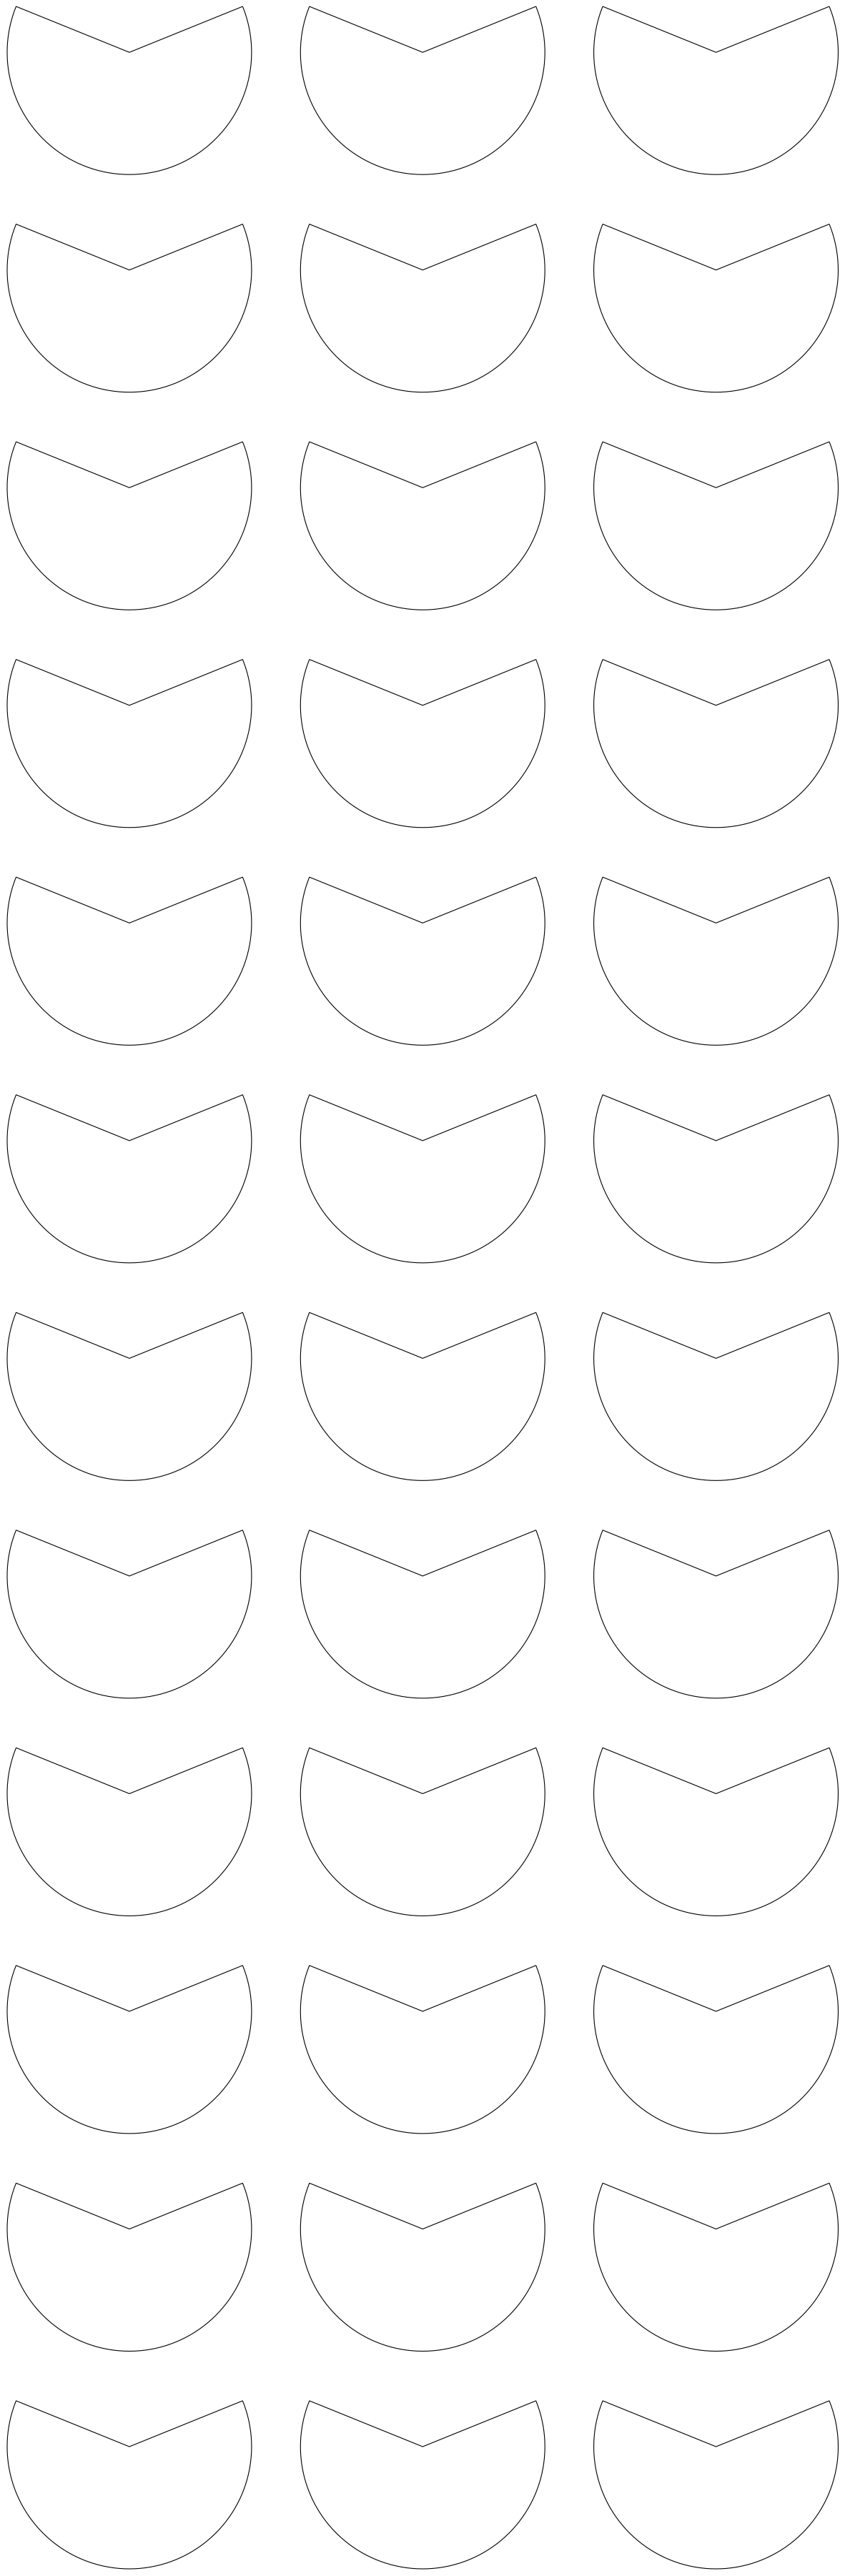

In [74]:
ncol = 3
nrow = int(np.ceil(N_STEPS / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.9 * nrow), subplot_kw=dict(projection=proj_hrrr))
for k, ax in enumerate(axes.ravel()):
    if k >= N_STEPS:
        ax.set_visible(False); continue
    im, im2 = plot_goes_mrms(ax, goes_fc[k, i_ir], mrms_fc[k, i_refc], f"+{k+1} h  valid {str(valid_times[k])[11:16]} UTC")
    ax.set_extent(WY_EXTENT, crs=ccrs.PlateCarree())
    add_cities(ax, fontsize=6)
fig.suptitle(f"StormScope forecast over Wyoming, init {START_TIME_STORMSCOPE:%Y-%m-%d %H} UTC (z500 from FCN3)", y=1.0)
fig.colorbar(im2, ax=axes, orientation="horizontal", shrink=0.4, pad=0.03, label="Forecast MRMS composite reflectivity [dBZ]")
plt.savefig("outputs/wyoming_hourly.png", dpi=150); plt.show()



In [22]:
package_fcn3 = FCN3.load_default_package()
fcn3 = FCN3.load_model(package_fcn3)

with xr.open_dataset(package_fcn3.resolve("orography.nc")) as ds:
    z_surface = torch.as_tensor(ds["Z"][0].values)
z_surf_coords = OrderedDict({d: fcn3.input_coords()[d] for d in ["lat", "lon"]})
sp_model = DerivedSurfacePressure(
    p_levels=[50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 850, 925, 1000],
    surface_geopotential=z_surface,
    surface_geopotential_coords=z_surf_coords,
)
fcn3_sp = DiagnosticWrapper(px_model=fcn3, dx_model=sp_model)

aiwp = InterpModAFNO.from_pretrained()
aiwp.px_model = fcn3_sp
aiwp = aiwp.to(device).eval()

aiwp_out_coords = aiwp.output_coords(aiwp.input_coords())
lat_aiwp, lon_aiwp = aiwp_out_coords["lat"], aiwp_out_coords["lon"]
print("AIWP output grid:", lat_aiwp.shape, lon_aiwp.shape, "| variables:", len(aiwp_out_coords["variable"]))

AIWP output grid: (720,) (1440,) | variables: 73


In [5]:
x_aiwp, coords_aiwp = fetch_data(
    GFS(),
    time=time_aiwp,
    variable=aiwp.input_coords()["variable"],
    device=device,
)
print(x_aiwp.shape, {k: v.shape for k, v in coords_aiwp.items()})

Fetching GFS data:   0%|          | 0/72 [00:00<?, ?it/s]

2026-09-01 22:57:38.257 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 155879586-907058


Fetching GFS data:   0%|          | 0/72 [00:00<?, ?it/s]

2026-09-01 22:57:38.381 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 152785223-762721
2026-09-01 22:57:38.399 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 281331137-935781
2026-09-01 22:57:38.413 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 176972382-912702
2026-09-01 22:57:38.428 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 232691085-718288
2026-09-01 22:57:38.441 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 299837319-1309369


Fetching GFS data:   0%|          | 0/72 [00:00<?, ?it/s]

...

2026-09-01 22:57:39.205 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 197069082-596033
2026-09-01 22:57:39.219 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 196474537-594545
2026-09-01 22:57:39.232 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 218081249-643590


Fetching GFS data:   0%|          | 0/72 [00:01<?, ?it/s]

2026-09-01 22:57:39.329 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 212199457-774266
2026-09-01 22:57:39.331 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 214321697-1121235
2026-09-01 22:57:39.345 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 172891874-1168724
2026-09-01 22:57:39.359 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 0-882747
2026-09-01 22:57:39.374 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 409557484-986228
2026-09-01 22:57:39.387 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib f

Fetching GFS data: 100%|██████████| 72/72 [00:01<00:00, 60.21it/s]


2026-09-01 22:57:39.414 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20240717/12/atmos/gfs.t12z.pgrb2.0p25.f000 254127140-748614
torch.Size([1, 1, 72, 721, 1440]) {'time': (1,), 'lead_time': (1,), 'variable': (72,), 'lat': (721,), 'lon': (1440,)}


Run the interpolated FCN3 forecast far enough to cover the StormScope window and store the
hourly `z500` fields in an in-memory `XarrayBackend`. Time coordinates are re-based so that
`time` is the StormScope initialisation and `lead_time` runs 0…N h; this is what StormScope will
query for conditioning.


In [6]:
z500_var = np.array(["z500"])
io_aiwp = XarrayBackend()
io_aiwp.add_array(
    OrderedDict(time=time_ss, lead_time=lead_times, lat=lat_aiwp, lon=lon_aiwp), z500_var
)

fcn3.set_rng(seed=SEED)
n_total = model_gap_h + N_STEPS
for step, (x, cx) in tqdm(
    enumerate(aiwp.create_iterator(x_aiwp.clone(), coords_aiwp.copy())),
    total=n_total + 1, desc="FCN3 + InterpModAFNO (hourly)",
):
    if step >= model_gap_h:
        x, cx = map_coords(x, cx, OrderedDict({"variable": z500_var}))
        cx = cx.copy()
        cx["time"] = time_ss
        cx["lead_time"] = cx["lead_time"] - np.timedelta64(model_gap_h, "h")
        io_aiwp.write(*split_coords(x, cx))
    if step == n_total:
        break

ds_z500 = io_aiwp.root
ds_z500

FCN3 + InterpModAFNO (hourly):  92%|█████████▏| 12/13 [00:26<00:02,  2.20s/it]


<xarray.Dataset> Size: 58MB
Dimensions:    (time: 1, lead_time: 7, lat: 720, lon: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2024-07-17T18:00:00
  * lead_time  (lead_time) timedelta64[s] 56B 00:00:00 01:00:00 ... 06:00:00
  * lat        (lat) float64 6kB 90.0 89.75 89.5 89.25 ... -89.25 -89.5 -89.75
  * lon        (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Data variables:
    z500       (time, lead_time, lat, lon) float64 58MB 5.296e+04 ... 4.92e+04

## 2. StormScope models conditioned on the AIWP forecast

In [7]:
# Expose the stored AIWP z500 as an earth2studio data source keyed by valid time
z500_source = InferenceOutputSource(ds_z500)

package_ss = StormScopeBase.load_default_package()
print(StormScopeGOES.list_available_models(package_ss))

# GOES model: conditioned on z500 -> conditioning source is the AIWP forecast
model_goes = StormScopeGOES.load_model(
    package=package_ss, model_name="6km_1hr", conditioning_data_source=z500_source, amp=True
).to(device).eval()

# MRMS model: conditioned on GOES, which we pass explicitly during the coupled rollout
model_mrms = StormScopeMRMS.load_model(
    package=package_ss, model_name="6km_1hr", conditioning_data_source=None, amp=True
).to(device).eval()

print("GOES state:", model_goes.variables, "| conditioning:", model_goes.conditioning_variables)
print("MRMS state:", model_mrms.variables, "| conditioning:", model_mrms.conditioning_variables)
print("Model grid:", tuple(model_goes.latitudes.shape))

{'3km_10min': {'description': 'CONUS nowcasting - 3 km / 10 min (recommended)', 'deprecated': False}, '6km_1hr': {'description': '6 km / 60 min nearcasting (legacy)', 'deprecated': True}}
2026-09-01 22:58:06.006 | WARNING  | earth2studio.models.px.stormscope:_resolve_model_entry:361 - StormScope '6km_1hr' is a legacy (nearcasting) checkpoint kept for backwards compatibility; the supported defaults are the CONUS nowcasting variants. See list_available_models() for alternatives.
2026-09-01 22:58:11.662 | WARNING  | earth2studio.models.px.stormscope:_resolve_model_entry:361 - StormScope '6km_1hr' is a legacy (nearcasting) checkpoint kept for backwards compatibility; the supported defaults are the CONUS nowcasting variants. See list_available_models() for alternatives.
2026-09-01 22:58:17.273 | WARNING  | earth2studio.models.px.stormscope:__init__:193 - No conditioning data source was provided to StormScope; set the conditioning_data_source attribute of the model before running inference w

### Initial conditions and regridding

StormScope works on a (downsampled) HRRR Lambert-conformal grid. Each model owns nearest-neighbour
interpolators: one for its own state (GOES or MRMS native grid → model grid) and one for its
conditioning (the AIWP 0.25° lat/lon grid for GOES; the GOES grid for MRMS).


In [8]:
goes_sat, scan_mode = "goes16", "C"   # GOES-16 was GOES-East in 2024 (GOES-19 from April 2025)
goes = GOES(satellite=goes_sat, scan_mode=scan_mode)
goes_lat, goes_lon = GOES.grid(satellite=goes_sat, scan_mode=scan_mode)

model_goes.build_input_interpolator(goes_lat, goes_lon)
model_goes.build_conditioning_interpolator(lat_aiwp, lon_aiwp)

in_coords_goes = model_goes.input_coords()
x_goes, coords_goes = fetch_data(
    goes, time=time_ss, variable=in_coords_goes["variable"],
    lead_time=in_coords_goes["lead_time"], device=device,
)

mrms = MRMS()
in_coords_mrms = model_mrms.input_coords()
x_mrms, coords_mrms = fetch_data(
    mrms, time=time_ss, variable=in_coords_mrms["variable"],
    lead_time=in_coords_mrms["lead_time"], device=device,
)
model_mrms.build_input_interpolator(coords_mrms["lat"], coords_mrms["lon"])
model_mrms.build_conditioning_interpolator(goes_lat, goes_lon)

# Add the batch dimension [B, T, L, C, H, W]; B>1 would give an ensemble
for name in ("goes", "mrms"):
    x, c = (x_goes, coords_goes) if name == "goes" else (x_mrms, coords_mrms)
    if x.dim() == 5:
        x = x.unsqueeze(0)
        c["batch"] = np.arange(1)
        c.move_to_end("batch", last=False)
    x = x.to(torch.float32)
    if name == "goes":
        x_goes, coords_goes = x, c
    else:
        x_mrms, coords_mrms = x, c
print("GOES IC", tuple(x_goes.shape), "| MRMS IC", tuple(x_mrms.shape))

2026-09-01 22:58:19.347 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:643 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (0.0).


Fetching GOES data:   0%|          | 0/1 [00:01<?, ?it/s]

2026-09-01 22:58:22.868 | DEBUG    | earth2studio.data.goes:fetch_array:356 - Fetching GOES file: noaa-goes16/ABI-L2-MCMIPC/2024/199/18/OR_ABI-L2-MCMIPC-M6_G16_s20241991801180_e20241991803565_c20241991804073.nc


Fetching MRMS data:   0%|          | 0/1 [00:02<?, ?it/s]

2026-09-01 22:58:26.334 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20240717/MRMS_MergedReflectivityQCComposite_00.50_20240717-180041.grib2.gz


Fetching MRMS data: 100%|██████████| 1/1 [00:04<00:00,  4.87s/it]


2026-09-01 22:58:36.677 | WARNING  | earth2studio.models.px.stormscope:build_input_interpolator:643 - Some input gridpoints are invalid after interpolation. This may be expected if the input data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (-0.25285158).
2026-09-01 22:58:38.184 | WARNING  | earth2studio.models.px.stormscope:build_conditioning_interpolator:689 - Some conditioning gridpoints are invalid after interpolation. This may be expected if the conditioning data source is not available at all gridpoints, but consider double-checking coordinates and/or the max_dist_km parameter. Invalid points will be filled with the model's _INPUT_INVALID_FILL_CONSTANT (-0.25285158).
GOES IC (1, 1, 1, 8, 1500, 2500) | MRMS IC (1, 1, 1, 1, 3500, 7000)


### Coupled rollout

Each hour: the GOES model advances the satellite state (it fetches the AIWP `z500` for the
current valid time internally through its conditioning source), then the MRMS model advances the
radar state conditioned on the *current* GOES state. Predictions are collected on the model grid.


In [9]:
lat_m = model_goes.latitudes.cpu().numpy()
lon_m = model_goes.longitudes.cpu().numpy()
lon_m180 = np.where(lon_m > 180, lon_m - 360, lon_m)
i_ir = list(model_goes.variables).index("abi13c")
i_refc = list(model_mrms.variables).index("refc")

torch.manual_seed(SEED)
y, yc = x_goes, coords_goes
ym, ymc = x_mrms, coords_mrms

goes_frames, mrms_frames, valid_times = [], [], []
for step in tqdm(range(N_STEPS), desc="StormScope coupled rollout"):
    y_pred, y_pred_c = model_goes(y, yc)
    ym_pred, ym_pred_c = model_mrms.call_with_conditioning(ym, ymc, conditioning=y, conditioning_coords=yc)

    goes_frames.append(torch.where(model_goes.valid_mask, y_pred, torch.nan)[0, 0, 0].cpu())
    mrms_frames.append(torch.where(model_mrms.valid_mask, ym_pred, torch.nan)[0, 0, 0].cpu())
    valid_times.append(y_pred_c["time"][0] + y_pred_c["lead_time"][0])

    y, yc = model_goes.next_input(y_pred, y_pred_c, y, yc)
    ym, ymc = model_mrms.next_input(ym_pred, ym_pred_c, ym, ymc)

goes_fc = torch.stack(goes_frames).numpy()   # [N_STEPS, C_goes, H, W]
mrms_fc = torch.stack(mrms_frames).numpy()   # [N_STEPS, C_mrms, H, W]
valid_times = np.array(valid_times)
print(goes_fc.shape, mrms_fc.shape, valid_times)

StormScope coupled rollout: 100%|██████████| 6/6 [01:37<00:00, 16.27s/it]

(6, 8, 512, 896) (6, 1, 512, 896) ['2024-07-17T19:00:00.000000000' '2024-07-17T20:00:00.000000000'
 '2024-07-17T21:00:00.000000000' '2024-07-17T22:00:00.000000000'
 '2024-07-17T23:00:00.000000000' '2024-07-18T00:00:00.000000000']


## 3. Wyoming analysis

### CONUS context with the Wyoming box


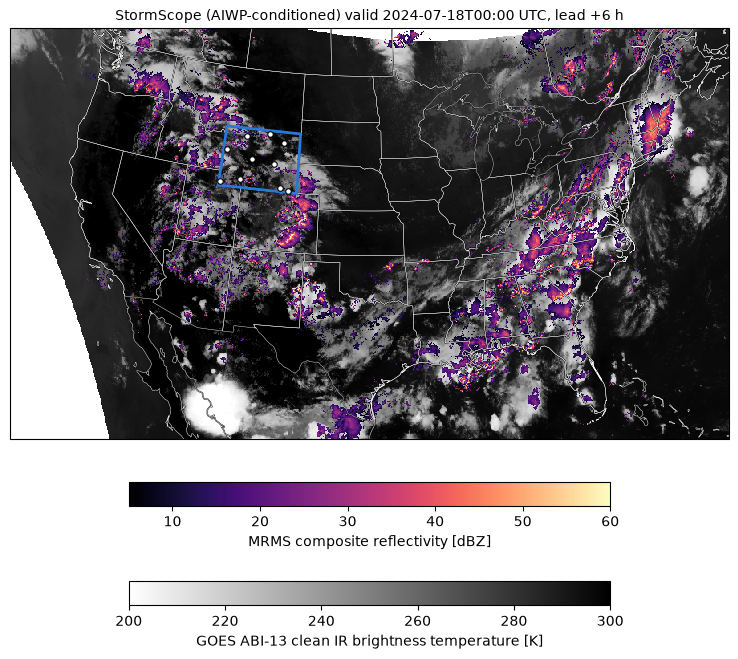

In [10]:
proj_hrrr = ccrs.LambertConformal(
    central_longitude=262.5, central_latitude=38.5, standard_parallels=(38.5, 38.5),
    globe=ccrs.Globe(semimajor_axis=6371229, semiminor_axis=6371229),
)
WY_EXTENT = [WY["lon_min"] - 0.5, WY["lon_max"] + 0.5, WY["lat_min"] - 0.5, WY["lat_max"] + 0.5]

def add_borders(ax):
    ax.coastlines(color="black", linewidth=1.0)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.8)
    ax.coastlines(color="white", linewidth=0.35)
    ax.add_feature(cfeature.STATES, edgecolor="white", linewidth=0.3)

def draw_wy_box(ax, **kw):
    lons = [WY["lon_min"], WY["lon_max"], WY["lon_max"], WY["lon_min"], WY["lon_min"]]
    lats = [WY["lat_min"], WY["lat_min"], WY["lat_max"], WY["lat_max"], WY["lat_min"]]
    ax.plot(lons, lats, transform=ccrs.PlateCarree(), **kw)

def add_cities(ax, color="white", edge="black", fontsize=7, label=True):
    # Mark the Wyoming cities with a dot and (optionally) a name label
    for name, (lat, lon) in WY_CITIES.items():
        ax.plot(lon, lat, marker="o", markersize=4, markerfacecolor=color, markeredgecolor=edge,
                markeredgewidth=0.8, linestyle="none", transform=ccrs.PlateCarree(), zorder=10)
        if label:
            ax.annotate(name, xy=(lon, lat), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                        xytext=(4, 3), textcoords="offset points", fontsize=fontsize, color=color,
                        path_effects=[pe.withStroke(linewidth=1.5, foreground=edge)], zorder=11)

def plot_goes_mrms(ax, ir, refc, title):
    im = ax.pcolormesh(lon_m, lat_m, ir, transform=ccrs.PlateCarree(), cmap="gray_r", shading="auto", vmin=200, vmax=300)
    refc_masked = np.where(refc <= 5, np.nan, refc)
    im2 = ax.pcolormesh(lon_m, lat_m, refc_masked, transform=ccrs.PlateCarree(), cmap="magma", shading="auto", vmin=5, vmax=60)
    add_borders(ax)
    ax.set_title(title, fontsize=10)
    return im, im2

k = N_STEPS - 1
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj_hrrr)
im, im2 = plot_goes_mrms(ax, goes_fc[k, i_ir], mrms_fc[k, i_refc],
                         f"StormScope (AIWP-conditioned) valid {str(valid_times[k])[:16]} UTC, lead +{k+1} h")
draw_wy_box(ax, color="#2a78d6", linewidth=2)
add_cities(ax, label=False)
plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.03, shrink=0.45, label="GOES ABI-13 clean IR brightness temperature [K]")
plt.colorbar(im2, ax=ax, orientation="horizontal", pad=0.08, shrink=0.45, label="MRMS composite reflectivity [dBZ]")
plt.tight_layout(); plt.savefig("outputs/conus_final_step.png", dpi=150); plt.show()

### AIWP conditioning: FCN3 `z500` over the western US

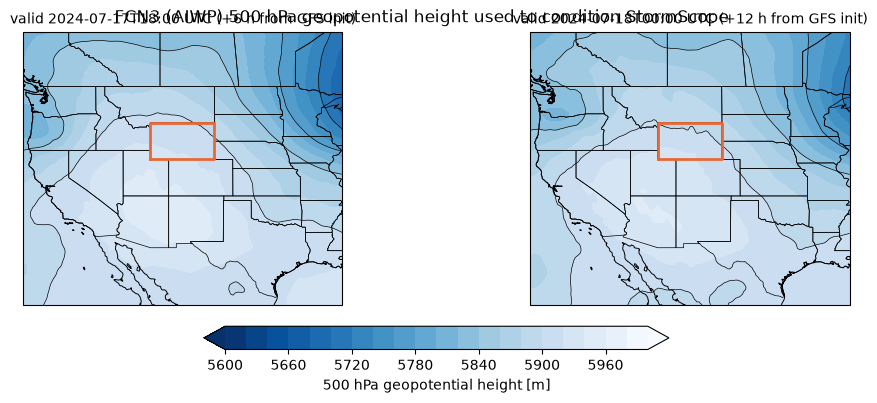

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), subplot_kw=dict(projection=ccrs.PlateCarree()))
for ax, li in zip(axes, [0, N_STEPS]):
    z = ds_z500["z500"].isel(time=0, lead_time=li) / 9.80665  # geopotential -> geopotential height [m]
    z = z.sel(lat=slice(55, 25))
    z = z.assign_coords(lon=(((z.lon + 180) % 360) - 180)).sortby("lon").sel(lon=slice(-125, -90))
    cf = ax.contourf(z.lon, z.lat, z, levels=np.arange(5600, 6001, 20), cmap="Blues_r", extend="both")
    ax.contour(z.lon, z.lat, z, levels=np.arange(5600, 6001, 60), colors="black", linewidths=0.5)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.5)
    ax.coastlines(linewidth=0.7)
    draw_wy_box(ax, color="#eb6834", linewidth=2)
    vt = str(np.datetime64(time_ss[0]) + lead_times[li])[:16]
    ax.set_title(f"valid {vt} UTC (+{model_gap_h + li} h from GFS init)", fontsize=10)
fig.suptitle("FCN3 (AIWP) 500 hPa geopotential height used to condition StormScope", y=0.93)
fig.colorbar(cf, ax=axes, orientation="horizontal", shrink=0.5, pad=0.06, label="500 hPa geopotential height [m]")
plt.savefig("outputs/aiwp_z500.png", dpi=150); plt.show()

### Hourly Wyoming zoom: forecast reflectivity on forecast IR

Major towns (Cheyenne, Laramie, Casper, Gillette, Rock Springs, Sheridan, Jackson, Evanston,
Riverton, Cody) are marked for orientation.

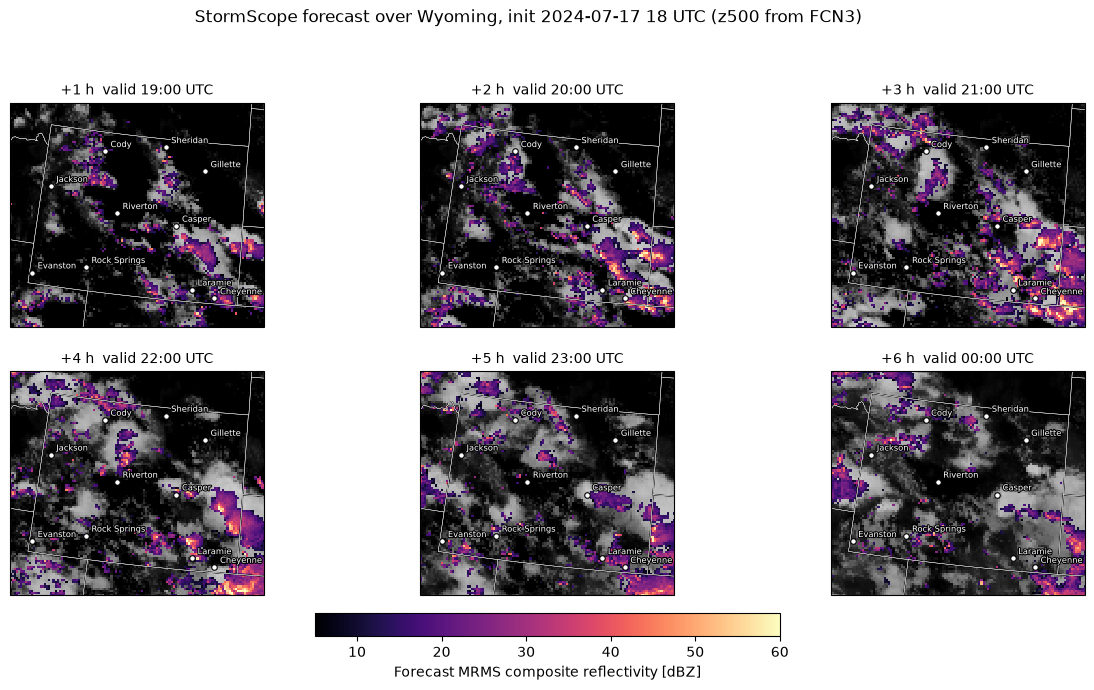

In [12]:
ncol = 3
nrow = int(np.ceil(N_STEPS / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.9 * nrow), subplot_kw=dict(projection=proj_hrrr))
for k, ax in enumerate(axes.ravel()):
    if k >= N_STEPS:
        ax.set_visible(False); continue
    im, im2 = plot_goes_mrms(ax, goes_fc[k, i_ir], mrms_fc[k, i_refc], f"+{k+1} h  valid {str(valid_times[k])[11:16]} UTC")
    ax.set_extent(WY_EXTENT, crs=ccrs.PlateCarree())
    add_cities(ax, fontsize=6)
fig.suptitle(f"StormScope forecast over Wyoming, init {START_TIME_STORMSCOPE:%Y-%m-%d %H} UTC (z500 from FCN3)", y=1.0)
fig.colorbar(im2, ax=axes, orientation="horizontal", shrink=0.4, pad=0.03, label="Forecast MRMS composite reflectivity [dBZ]")
plt.savefig("outputs/wyoming_hourly.png", dpi=150); plt.show()

### Verification against observed MRMS over Wyoming

Fetch the observed composite reflectivity at each valid time, regrid it with the MRMS model's own
nearest-neighbour interpolator so both fields live on the same grid, and compare inside the
Wyoming box. This is a single deterministic sample, so treat the numbers as a sanity check, not a
skill score.


In [13]:
x_obs, c_obs = fetch_data(mrms, time=time_ss, variable=np.array(["refc"]), lead_time=lead_times[1:], device=device)
x_obs = model_mrms.input_interp(x_obs.to(torch.float32))          # -> [T, L, C, H, W] on the model grid
mrms_obs = torch.where(model_mrms.valid_mask, x_obs, torch.nan)[0, :, 0].cpu().numpy()  # [N_STEPS, H, W]

wy_mask = (lat_m >= WY["lat_min"]) & (lat_m <= WY["lat_max"]) & (lon_m180 >= WY["lon_min"]) & (lon_m180 <= WY["lon_max"])
print(f"Wyoming box: {wy_mask.sum()} model grid points")

def box_stats(field):
    v = field[wy_mask]
    v = v[np.isfinite(v)]
    return dict(max_dBZ=float(np.nanmax(v)), frac_ge35=float(np.mean(v >= 35)), frac_ge20=float(np.mean(v >= 20)))

rows = []
for k in range(N_STEPS):
    f, o = box_stats(mrms_fc[k, i_refc]), box_stats(mrms_obs[k])
    rows.append(dict(lead_h=k + 1, valid=str(valid_times[k])[:16],
                     fc_max=f["max_dBZ"], obs_max=o["max_dBZ"],
                     fc_frac_ge35=f["frac_ge35"], obs_frac_ge35=o["frac_ge35"],
                     fc_frac_ge20=f["frac_ge20"], obs_frac_ge20=o["frac_ge20"]))
verif = pd.DataFrame(rows).set_index("lead_h")
verif.round(3)

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xfff8ce6eb8c0>
Fetching MRMS data:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-01 23:00:29.867 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20240717/MRMS_MergedReflectivityQCComposite_00.50_20240717-190042.grib2.gz


Fetching MRMS data:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-01 23:00:32.648 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20240717/MRMS_MergedReflectivityQCComposite_00.50_20240717-200045.grib2.gz


Fetching MRMS data:   0%|          | 0/1 [00:00<?, ?it/s]

...

Fetching MRMS data:   0%|          | 0/1 [00:02<?, ?it/s]

2026-09-01 23:00:46.438 | INFO     | earth2studio.data.mrms:_fetch_task:297 - Fetching MRMS file: s3://noaa-mrms-pds/CONUS/MergedReflectivityQCComposite_00.50/20240718/MRMS_MergedReflectivityQCComposite_00.50_20240718-000043.grib2.gz


Fetching MRMS data: 100%|██████████| 1/1 [00:04<00:00,  4.59s/it]


Wyoming box: 7076 model grid points


,valid,fc_max,obs_max,fc_frac_ge35,obs_frac_ge35,fc_frac_ge20,obs_frac_ge20
lead_h,,,,,,,
1,2024-07-17T19:00,51.848,57.5,0.009,0.009,0.055,0.056
2,2024-07-17T20:00,65.647,57.0,0.017,0.010,0.079,0.080
3,2024-07-17T21:00,66.042,54.0,0.023,0.009,0.104,0.078
4,2024-07-17T22:00,63.425,57.5,0.016,0.008,0.077,0.074
5,2024-07-17T23:00,53.134,57.5,0.007,0.009,0.049,0.076
6,2024-07-18T00:00,63.826,49.5,0.004,0.006,0.033,0.054


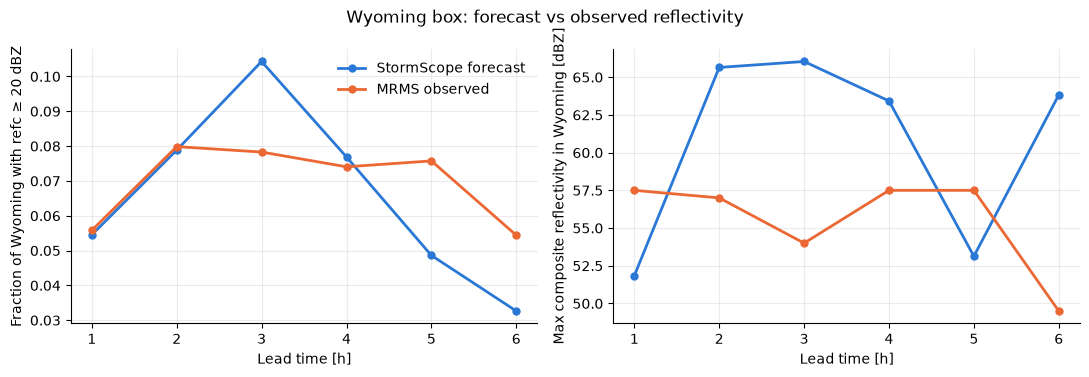

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
h = verif.index.values
for ax, col, ylabel in [(axes[0], "frac_ge20", "Fraction of Wyoming with refc ≥ 20 dBZ"),
                        (axes[1], "max_dBZ", "Max composite reflectivity in Wyoming [dBZ]")]:
    fc_col, obs_col = (f"fc_{col}", f"obs_{col}") if col != "max_dBZ" else ("fc_max", "obs_max")
    ax.plot(h, verif[fc_col], color="#2a78d6", linewidth=2, marker="o", markersize=5, label="StormScope forecast")
    ax.plot(h, verif[obs_col], color="#eb6834", linewidth=2, marker="o", markersize=5, label="MRMS observed")
    ax.set_xlabel("Lead time [h]"); ax.set_ylabel(ylabel)
    ax.set_xticks(h); ax.grid(alpha=0.25); ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(frameon=False)
fig.suptitle("Wyoming box: forecast vs observed reflectivity")
plt.tight_layout(); plt.savefig("outputs/wyoming_verification.png", dpi=150); plt.show()

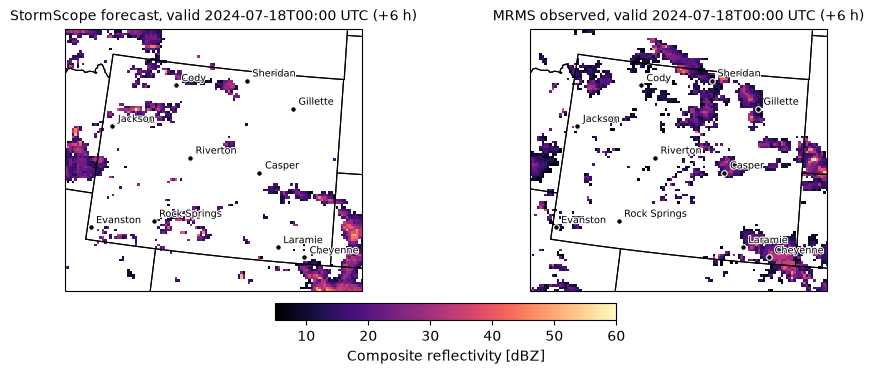

In [15]:
# Side-by-side forecast vs observed reflectivity over Wyoming at the final step
k = N_STEPS - 1
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), subplot_kw=dict(projection=proj_hrrr))
for ax, field, name in [(axes[0], mrms_fc[k, i_refc], "StormScope forecast"), (axes[1], mrms_obs[k], "MRMS observed")]:
    im2 = ax.pcolormesh(lon_m, lat_m, np.where(field <= 5, np.nan, field), transform=ccrs.PlateCarree(),
                        cmap="magma", shading="auto", vmin=5, vmax=60)
    ax.add_feature(cfeature.STATES, edgecolor="black", linewidth=0.8)
    ax.set_extent(WY_EXTENT, crs=ccrs.PlateCarree())
    add_cities(ax, color="black", edge="white", fontsize=7)
    ax.set_title(f"{name}, valid {str(valid_times[k])[:16]} UTC (+{k+1} h)", fontsize=10)
fig.colorbar(im2, ax=axes, orientation="horizontal", shrink=0.4, pad=0.04, label="Composite reflectivity [dBZ]")
plt.savefig("outputs/wyoming_fc_vs_obs.png", dpi=150); plt.show()

### Export the Wyoming cut-out

In [16]:
ys, xs = np.where(wy_mask)
sl = (slice(ys.min(), ys.max() + 1), slice(xs.min(), xs.max() + 1))
ds_out = xr.Dataset(
    {
        **{v: (("lead_time", "y", "x"), goes_fc[:, i, sl[0], sl[1]]) for i, v in enumerate(model_goes.variables)},
        "refc": (("lead_time", "y", "x"), mrms_fc[:, i_refc, sl[0], sl[1]]),
        "refc_obs": (("lead_time", "y", "x"), mrms_obs[:, sl[0], sl[1]]),
    },
    coords=dict(
        lead_time=lead_times[1:], y=model_goes.y[sl[0]], x=model_goes.x[sl[1]],
        lat=(("y", "x"), lat_m[sl]), lon=(("y", "x"), lon_m180[sl]),
        time=np.datetime64(time_ss[0]),
    ),
    attrs=dict(
        title="StormScope 6km_1hr forecast over Wyoming, z500 conditioning from FCN3+InterpModAFNO",
        aiwp_init=str(START_TIME_AIWP), stormscope_init=str(START_TIME_STORMSCOPE), seed=SEED,
        grid="HRRR Lambert conformal, 2x downsampled (6 km)",
    ),
)
ds_out.to_netcdf("outputs/stormscope_aiwp_wyoming.nc")
ds_out

<xarray.Dataset> Size: 2MB
Dimensions:    (lead_time: 6, y: 84, x: 102)
Coordinates:
  * lead_time  (lead_time) timedelta64[s] 48B 01:00:00 02:00:00 ... 06:00:00
  * y          (y) float64 672B 2.997e+05 3.057e+05 ... 7.917e+05 7.977e+05
  * x          (x) float64 816B -1.129e+06 -1.123e+06 ... -5.285e+05 -5.225e+05
    lat        (y, x) float32 34kB 40.46 40.46 40.47 40.48 ... 45.48 45.48 45.49
    lon        (y, x) float32 34kB -110.9 -110.8 -110.7 ... -104.3 -104.2 -104.2
    time       datetime64[ns] 8B 2024-07-17T18:00:00
Data variables:
    abi01c     (lead_time, y, x) float32 206kB 0.3194 0.1403 ... 0.1569 0.1483
    abi02c     (lead_time, y, x) float32 206kB 0.2664 0.08756 ... 0.1027 0.09923
    abi03c     (lead_time, y, x) float32 206kB 0.3642 0.1753 ... 0.1561 0.1437
    abi07c     (lead_time, y, x) float32 206kB 284.4 306.8 309.9 ... 304.5 304.1
    abi08c     (lead_time, y, x) float32 206kB 233.9 236.7 238.3 ... 242.3 242.5
    abi09c     (lead_time, y, x) float32 206kB 238.5 244.0 246.2 ... 252.0 252.2
    abi10c     (lead_time, y, x) float32 206kB 242.5 250.8 253.3 ... 260.5 260.5
    abi13c     (lead_time, y, x) float32 206kB 264.8 297.0 299.4 ... 297.2 297.9
    refc       (lead_time, y, x) float32 206kB -9.797 -9.793 ... -9.803 -9.803
    refc_obs   (lead_time, y, x) float32 206kB 16.5 13.0 11.0 ... -99.0 -99.0
Attributes:
    title:            StormScope 6km_1hr forecast over Wyoming, z500 conditio...
    aiwp_init:        2024-07-17 12:00:00
    stormscope_init:  2024-07-17 18:00:00
    seed:             1234
    grid:             HRRR Lambert conformal, 2x downsampled (6 km)

## Where to go from here

* **Ensemble**: repeat the batch dimension (`x_goes.repeat(B, ...)`) and/or loop over FCN3 seeds
  with `fcn3.set_rng(seed)` to get a StormScope ensemble driven by an AIWP ensemble; the same
  structure is used by the `foundry_fcn3_stormscope_goes` serving workflow.
* **Swap the AIWP model**: any earth2studio prognostic model that outputs `z500` on a lat/lon grid
  works as the conditioning source. Models without the 73 InterpModAFNO channels can be
  interpolated in time by hand (z500 is smooth at hourly scale).
* **Longer AIWP lead**: increase the gap between `START_TIME_AIWP` and `START_TIME_STORMSCOPE` to
  see how conditioning from a day-old AIWP forecast changes the nowcast.
